# Sistema de agrupación de casas

In [192]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from utils2 import get_classifier_metrics
import pickle
from sklearn.preprocessing import MinMaxScaler

## Definición del problema

> - Conocer cuales són los lugares deonde tengo casas mas grandes o mas pequeñas.

## EDA

### Recopilación de datos

> Dataset de [housing.csv](https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv)

In [193]:
df = pd.read_csv("../data/raw/housing.csv")

### Analisis descriptivo

In [194]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


> En este caso solo me interesan las columnas `Latitude`, `Longitude` y `MedInc`.

In [195]:
df = df[['Latitude', 'Longitude', 'MedInc']]
df.head()

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   20640 non-null  float64
 1   Longitude  20640 non-null  float64
 2   MedInc     20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


#### Observaciones:
> - Existes un total de 20640 filas y 3 columnas.
> - Ninguna de las características presetan valores nulos.

### Limpieza de Datos

In [197]:
df.duplicated().sum()

np.int64(5)

In [198]:
df.drop_duplicates(inplace=True)

> Ahora el DataFrame está libre de duplicados


## Construye un K-Means

#### Normalización

In [199]:
# Entrenar el modelo
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)

In [200]:
df_scaled

,Latitude,Longitude,MedInc
0,0.567481,0.211155,0.539668
1,0.565356,0.212151,0.538027
2,0.564293,0.210159,0.466028
3,0.564293,0.209163,0.354699
4,0.564293,0.209163,0.230776
...,...,...,...
20635,0.737513,0.324701,0.073130
20636,0.738576,0.312749,0.141853
20637,0.732200,0.311753,0.082764
20638,0.732200,0.301793,0.094295


#### Observaciones:
> - Primero se deben escalar las características.
> - Una vez llamado al modelo se entrena y se predice guardando los valores de las predicciones en una nueva tabla llamada cluster la cual se define como categoría para que los numeros no sean valores matematicos, sino que sean leidos como etiquetas.


### Visualización

In [201]:
# Usamos las columnas reales de tu dataset
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=df['Longitude'], 
    y=df['Latitude'], 
    hue=df['cluster'],
    alpha=0.6
)

plt.title('Clasificación Geográfica de Casas (6 Clusters)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Cluster')

KeyError: 'cluster'

<Figure size 1000x800 with 0 Axes>

#### Observaciones: 
> -  El algoritmo ha dividido el mapa de California en regiones.
> - Algunos colores se solapan en la misma zona porque las viviendas no solo estan separadas por dónde están, sino por el nivel adquisitivo de la zona.
> - Los clusters son mas densos en las zonas costeras, lo que indica que K-means detecta doónde hay mayor concentración de viviendas.
> -  Devido  a `MinMaxScaker` el modelo pudo tratar todas las variables por igual.

In [ ]:
with open('../models/housing_kmeans_model.pkl', 'wb') as file:
    pickle.dump(model, file)

## Split

In [ ]:
X = df.drop('cluster', axis=1)
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

### Random Forest

In [ ]:
rf_model = RandomForestClassifier(max_depth=5, min_samples_leaf=10, n_estimators=100, random_state=18)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
rf_model.feature_importances_

array([0.33579936, 0.31616328, 0.34803736])

In [ ]:
y_pred_test = rf_model.predict(X_test)
y_pred_train = rf_model.predict(X_train)
y_pred_test, y_pred_train

(array([5, 0, 2, ..., 5, 0, 5], shape=(4127,), dtype=int32),
 array([5, 4, 5, ..., 1, 1, 4], shape=(16508,), dtype=int32))

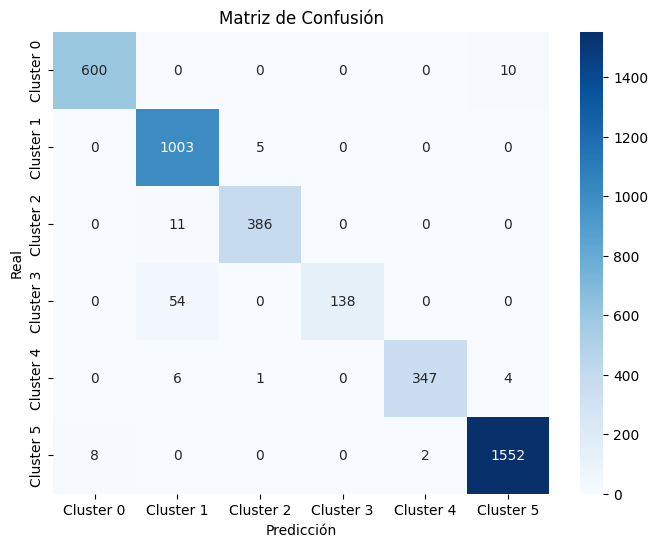

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(6)],
            yticklabels=[f'Cluster {i}' for i in range(6)])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

#### Observaciones:
> - Esta Matriz de Confusión es una herramienta excelente para validar la segmentación. Lo que se visualiza es qué tan bien el modelo Random Forest es capaz de reconocer los grupos que creó el K-Means.
> - La diagonal principal (los números más altos) está muy marcada, lo que confirma que los clusters no son aleatorios.
> - El Cluster 5 es el más grande con 1552 aciertos. Sin embargo, tiene pequeñas confusiones con el Cluster 0 (8 casos) y el Cluster 4 (2 casos). Esto sugiere que el Cluster 5 es el elnucleo, el grupo mayoritario de los datos, y algunos de sus miembros están en la frontera con los grupos 0 y 4.
> - En la fila del Cluster 3: hay 54 registros que el modelo clasificó erróneamente como Cluster 1.

In [ ]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,0.974740,0.974740,0.974740,0.974740
Test set,0.975527,0.975527,0.975527,0.975527


#### Observaciones:
> - Train set y el Test set tienen resultados casi idénticos (0.97). Eso es la señal de un modelo robusto que generalizará bien con datos que nunca ha visto.

In [ ]:
X_test_scaled = scaler.transform(X_test) 

# 2. Predecir los clusters para el conjunto de test
test_clusters = rf_model.predict(X_test_scaled)

# 3. Guardar en el DataFrame de test (para graficar)
X_test['cluster'] = test_clusters
X_test['cluster'] = X_test['cluster'].astype('category')

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


### Visualización de las predicciones.

Text(0.5, 1.0, 'Validación de Clusters: Train (puntos) vs Test (X)')

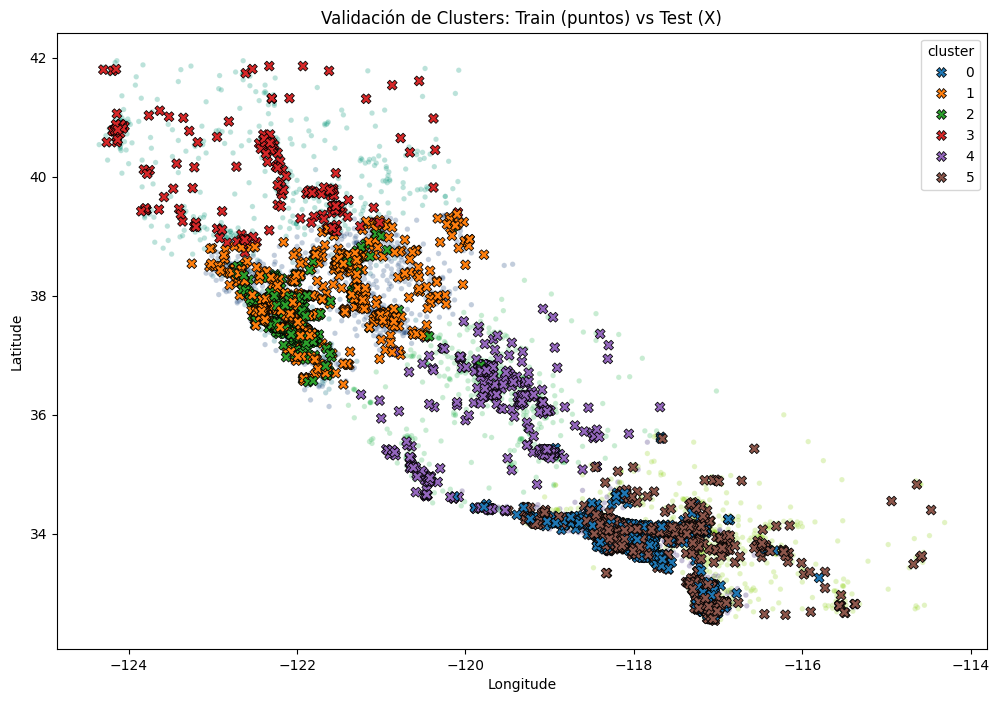

In [ ]:
plt.figure(figsize=(12, 8))

# Graficar datos de Entrenamiento (como fondo)
sns.scatterplot(
    data=df, x='Longitude', y='Latitude', hue='cluster', 
    palette='viridis', alpha=0.3, s=15, legend=False
)

# Graficar datos de Test (encima, más grandes y con marcador 'X')
sns.scatterplot(
    data=X_test, x='Longitude', y='Latitude', hue='cluster', 
    marker='X', s=50, edgecolor='black'
)

plt.title('Validación de Clusters: Train (puntos) vs Test (X)')

##### Observaciones:
> - Para confirmar si la predicción es satisfactoria, grafico los datos de entrenamiento (puntos tenues) y los de test encima (las x) para ver si "encajan" en las mismas zonas.
> -  La predicción es satisfactoria porque los datos de test respetan los límites geográficos establecidos durante el entrenamiento.


In [ ]:
with open('../models/housing_rf_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

 ## Modelo de clasificación supervisada: (Elbow Method)

> -  El Método del Codo (Elbow Method) es uno de los más utilizados en la industria, no porque sea el más "exacto" matemáticamente, sino por su equilibrio entre simplicidad, interpretabilidad y eficiencia.

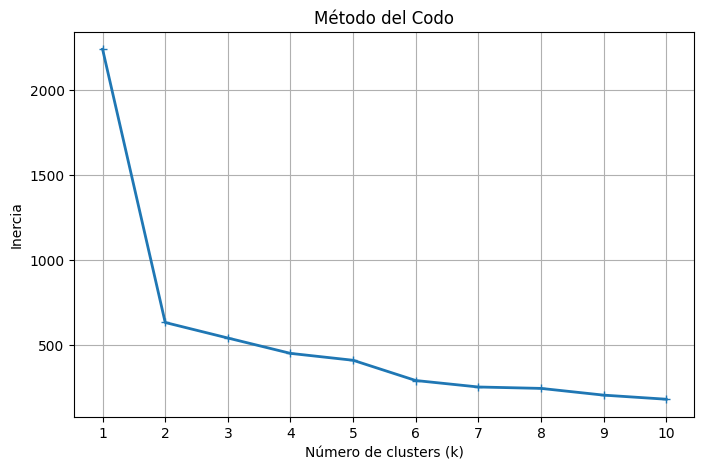

In [ ]:
inertias = []
K_values = range(1, 11)

for k in K_values:
    kmeans_model= KMeans(n_clusters=k, random_state=42)
    kmeans_model.fit(df_scaled)
    inertias.append(kmeans_model.inertia_)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(K_values, inertias, '+-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.xticks(K_values)
plt.grid(True)

In [ ]:
silhouette = silhouette_score(df_scaled, kmeans_model.labels_)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.3385


#### Observaciones:
> - El "Codo" principal: Se ve claramente en $k=2$. Ahí es donde la caída de la inercia es más drástica.
> - Elección de 6 clusters: En este gráfico, el valor 6 es defendible porque después de ese punto la curva se vuelve casi plana (la ganancia de información es mínima). Sin embargo, 2 o 4 también parecen candidatos fuertes.
> - Silhouette arroja un valor de 0.33, se considera aceptable, el modelo ha encontrado patrones reales, aunque existen zonas de solapamiento entre los clusters (algunos puntos están cerca de las fronteras de otro grupo).

In [ ]:
with open('../models/housing_rf_model.pkl', 'wb') as file:
    pickle.dump(kmeans_model, file)